# Python vizualizācija — Matplotlib, Seaborn un Plotly

Šī piezīmju grāmata (notebook) ir paredzēta lekcijai **“Python vizualizācija”** un balstās uz kursa aprakstu:
- Matplotlib pamati
- Seaborn statistiskās vizualizācijas
- Interaktīvās vizualizācijas ar Plotly
- Prezentācijām piemēroti grafiki

Konteksts: studenti iepriekšējā nodarbībā jau ir strādājuši ar **Pandas**, **Jupyter Notebooks** un **Google Colab**.

## Mācību mērķi
Pēc šīs nodarbības studentam jāspēj:
1. izveidot skaidru statisku grafiku ar **Matplotlib**;
2. izmantot **Seaborn** statistiskai datu izpētei;
3. izveidot interaktīvu grafiku ar **Plotly**;
4. izvēlēties piemērotu grafika tipu konkrētam jautājumam;
5. ievērot pamata labās prakses principus profesionālās vizualizācijās.

## Datu kopa
Tiek izmantota sintētiska, bet reālistiska datu kopa par reģioniem, izdevumu kategorijām un iedzīvotāju apmierinātību Latvijā.

**Fails:** `python_vizualizacija_dati.csv`


## 1. Sagatavošanās

Šajā sadaļā importēsim vajadzīgās bibliotēkas un ielādēsim datus.


In [1]:
# vispirms pārbaudam vai vispār strādā Notebook
print("Sveiki, Python vizualizāciju lekcija!")

Sveiki, Python vizualizāciju lekcija!


In [2]:
import pandas as pd
print(f"Pandas versija: {pd.__version__}")

Pandas versija: 3.0.2


In [3]:
# Šodienas datums un laiks
from datetime import datetime # šī ir iebūvētā bibliotēka, nav jāinstalē!
print(f"Šodien ir: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Šodien ir: 2026-04-09 14:07:40


In [4]:
# Ja strādājat Google Colab un nepieciešams Plotly/Seaborn jaunāks variants,
# var atkomentēt nākamo rindu:
# !pip install seaborn plotly -q

# šīs bibliotekas nav iebūvētas Python standarta bibliotēkā, 
# tāpēc tās ir jāinstalē, ja vēl nav pieejamas.
print("Ja ir kļūda tad bibliotēkas nav pieejamas, lūdzu instalējiet tās pirms turpināt.")
print("Instalējam no komandrindas, ja nepieciešams:")
# we also need openpyxl for reading Excel files, but in this case we are using CSV, so it's not required.
print("pip install pandas numpy matplotlib seaborn plotly openpyxl")
# Google Colab tām jau būtu jābūt pieejamām, bet vietējā vidē var būt nepieciešams tās instalēt.

import pandas as pd
import numpy as np
# Vizualizācijas bibliotēkas
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# ja nestrādā kāda no bibliotekām, var atkomentēt nākamo rindu un instalēt trūkstošo bibliotēku
print("Bibliotēkas ir pieejamas un gatavas lietošanai!")


# Labāka attēlu kvalitāte Jupyter/Colab vidē
plt.rcParams["figure.dpi"] = 130
sns.set_theme(style="whitegrid")




Ja ir kļūda tad bibliotēkas nav pieejamas, lūdzu instalējiet tās pirms turpināt.
Instalējam no komandrindas, ja nepieciešams:
pip install pandas numpy matplotlib seaborn plotly openpyxl
Bibliotēkas ir pieejamas un gatavas lietošanai!


In [ ]:
# Mēģinām nolasīt ārējo CSV failu.
# Ja fails nav pieejams, izveidojam to no iekšā definēta saraksta.
try:
    df = pd.read_csv("python_vizualizacija_dati.csv") # šo izmantotu lokāli, ja fails ir pieejams
except FileNotFoundError: # plāns B no publiskas adreses, ja fails nav pieejams
    df = pd.read_csv("https://raw.githubusercontent.com/ValRCS/RTU_Digitalas_Prasmes_Excel_VBA_Python/refs/heads/main/notebooks/python_vizualizacija_dati.csv")

df.head()

,gads,regions,kategorija,izdevumi_milj_eur,projektu_skaits,iedzivotaju_apmierinatiba,pakalpojuma_lietotaji
0,2020,Rīga,Izglītība,69.82,10,78.5,66597
1,2020,Rīga,Veselība,70.67,10,72.0,62339
2,2020,Rīga,Transports,59.94,9,70.0,57058
3,2020,Rīga,Kultūra,30.23,7,82.4,23771
4,2020,Rīga,Sociālā aizsardzība,47.54,6,72.0,42587


## 2. Datu iepazīšana

Pirms veidot grafikus, vienmēr jāsaprot:
- kādas ir kolonnas,
- kādi ir datu tipi,
- vai ir tukšas vērtības,
- kāds jautājums vispār tiek uzdots datiem.


In [6]:
# Izpētiet datu struktūru ar `df.info()`
# Papildu uzdevums: parādiet pirmās 5 rindas ar `df.head()` un aprakstiet katras kolonnas nozīmi
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   gads                       150 non-null    int64  
 1   regions                    150 non-null    str    
 2   kategorija                 150 non-null    str    
 3   izdevumi_milj_eur          150 non-null    float64
 4   projektu_skaits            150 non-null    int64  
 5   iedzivotaju_apmierinatiba  150 non-null    float64
 6   pakalpojuma_lietotaji      150 non-null    int64  
dtypes: float64(2), int64(3), str(2)
memory usage: 8.3 KB


In [7]:
# Izveidojiet kopsavilkumu skaitliskajām kolonnām ar `df.describe()`
# atceramies ka df.describe() parāda tikai skaitliskās kolonnas, ja vēlamies redzēt arī kategoriskās, var izmantot df.describe(include='all')
df.describe()


,gads,izdevumi_milj_eur,projektu_skaits,iedzivotaju_apmierinatiba,pakalpojuma_lietotaji
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,2022.500000,48.785200,8.066667,72.535333,43824.573333
std,1.713547,17.099131,3.142407,6.730718,15914.491051
min,2020.000000,16.020000,2.000000,56.200000,11022.000000
25%,2021.000000,35.672500,6.000000,67.325000,32325.250000
50%,2022.500000,48.950000,8.000000,72.100000,44037.000000
75%,2024.000000,60.442500,10.000000,77.275000,52782.500000
max,2025.000000,94.820000,16.000000,87.700000,88660.000000


In [8]:
# Izveidojiet kopsavilkumu visām kolonnām, ieskaitot kategoriskās, izmantojot `df.describe(...)`
df.describe(include='all')


,gads,regions,kategorija,izdevumi_milj_eur,projektu_skaits,iedzivotaju_apmierinatiba,pakalpojuma_lietotaji
count,150.000000,150,150,150.000000,150.000000,150.000000,150.000000
unique,NaN,5,5,NaN,NaN,NaN,NaN
top,NaN,Rīga,Izglītība,NaN,NaN,NaN,NaN
freq,NaN,30,30,NaN,NaN,NaN,NaN
mean,2022.500000,NaN,NaN,48.785200,8.066667,72.535333,43824.573333
std,1.713547,NaN,NaN,17.099131,3.142407,6.730718,15914.491051
min,2020.000000,NaN,NaN,16.020000,2.000000,56.200000,11022.000000
25%,2021.000000,NaN,NaN,35.672500,6.000000,67.325000,32325.250000
50%,2022.500000,NaN,NaN,48.950000,8.000000,72.100000,44037.000000
75%,2024.000000,NaN,NaN,60.442500,10.000000,77.275000,52782.500000


In [10]:
# Saglabājiet pilno kolonnu kopsavilkumu CSV failā `datu_apraksts.csv`
# Padoms: var noderēt `df.describe(include="all")`, transponēšana ar `.T` un `to_csv(...)`
df.describe(include="all").T.to_csv("datu_apraksts.csv", index=True)
# kāpēc index=True? 
# Jo pēc noklusējuma df.describe() atgriež DataFrame, kurā rindu nosaukumi ir kolonnās, 
# un tie tiek uzskatīti par indeksiem.
#  Ja mēs vēlamies saglabāt šos indeksus kā parastu kolonnu CSV failā, mums jānorāda index=True.
#  Tas nodrošinās, ka rindu nosaukumi tiek iekļauti CSV failā kā atsevišķa kolonna, nevis tiek izlaisti.

In [ ]:
# TODO bonuss uzdevums saglabājiet to pašu aprakstu Excel failā, izmantojot `to_excel(...)` metodi, un pārliecinieties, ka tas darbojas arī ar Excel formātu.

## 3. Labā prakse vizualizācijās

Pirms ķeramies pie bibliotēkām, paturiet prātā dažus principus.

### Pamatprincipi
1. **Grafikam jāatbild uz jautājumu**, nevis vienkārši jāizskatās iespaidīgi.
2. **Izvēlieties pareizo grafika tipu**:
   - laika rindām — line chart jeb līniju diagramma,
   - kategoriju salīdzināšanai — bar chart jeb stabiņu diagramma,
   - sadalījumiem — histogramma vai boxplot (latviski — kastīšu diagramma),
   - sakarībām starp skaitliskiem mainīgajiem — scatter plot jeb punktu diagramma.
3. **Nepārslogojiet grafiku** ar pārāk daudz krāsām, etiķetēm un dekorācijām.
4. **Nosaukums, asu nosaukumi un leģenda** nav izvēles greznība — tie ir obligāti.
5. **Krāsu lietojumam jābūt semantiski pamatotam**.
6. **Prezentācijām** vajag lielākus fontus, mazāk sīku detaļu un vienu galveno domu vienā grafikā.


## 4. Matplotlib pamati

### Kas ir Matplotlib?

Matplotlib ir Python bibliotēka, kas ļauj veidot statiskus, animētus un interaktīvus grafikus. Tā ir ļoti elastīga un ļauj pilnībā kontrolēt grafika izskatu, bet var būt nedaudz sarežģīta iesācējiem.

Labās ziņas - matplotlib ir ļoti labi dokumentēta un ir daudz piemēru, ko var izmantot kā pamatu saviem grafikiem.

### Dokumentācija

Oficial Matplotlib documentation: https://matplotlib.org/stable/contents.html

Ja jums ir uzstādīts Copilot vai kāds cits AI palīgs, varat izmantot to, lai ģenerētu kodu, pamatojoties uz Matplotlib dokumentāciju. Piemēram, varat lūgt ģenerēt kodu, lai izveidotu vienkāršu līniju diagrammu, un AI var sniegt jums piemēru, ko varat pielāgot saviem datiem.

Šajā sadaļā veidosiet savus pirmos statiskos grafikus.


### Uzdevums 4.1. Līniju grafiks pa gadiem

Izveidojiet tabulu, kur katram gadam ir aprēķināta **kopējā izdevumu summa**, un uzzīmējiet to kā līniju grafiku.

**Prasības:**
- izmantojiet `groupby()`,
- uzlieciet virsrakstu,
- nosauciet abas asis,
- pievienojiet režģi.


In [11]:
# Parādiet datu pirmās rindas ar `df.head()`
df.head()


,gads,regions,kategorija,izdevumi_milj_eur,projektu_skaits,iedzivotaju_apmierinatiba,pakalpojuma_lietotaji
0,2020,Rīga,Izglītība,69.82,10,78.5,66597
1,2020,Rīga,Veselība,70.67,10,72.0,62339
2,2020,Rīga,Transports,59.94,9,70.0,57058
3,2020,Rīga,Kultūra,30.23,7,82.4,23771
4,2020,Rīga,Sociālā aizsardzība,47.54,6,72.0,42587


In [12]:
# Pārbaudiet, cik ierakstu ir katram gadam, izmantojot `value_counts()` kolonnai `gads`
# Padoms: var noderēt `df["gads"].value_counts()`
df["gads"].value_counts()
# Īsi interpretējiet, vai dati pa gadiem ir vienmērīgi sadalīti


gads
2020    25
2021    25
2022    25
2023    25
2024    25
2025    25
Name: count, dtype: int64

In [ ]:
# Izveidojiet DataFrame `izdevumi_pa_gadiem`
# Grupējiet datus pēc `gads` un saskaitiet `izdevumi_milj_eur` summu
# Parādiet rezultāta pirmās rindas
izdevumi_pa_gadiem = df.groupby("gads")["izdevumi_milj_eur"].sum().reset_index()
# tātad mēs sagrupējām pēc gads kolonnas un 
# saskaitījām izdevumi_milj_eur kolonnas vērtības katram gadam, pēc tam resetējām indeksu, lai iegūtu kārtīgu DataFrame struktūru
izdevumi_pa_gadiem.head(10) # mums ir mazāk par 10 gadiem
# šeit arī varētu saglabāt failā rezultātu, piemēram, izdevumi_pa_gadiem.to_csv("izdevumi_pa_gadiem.csv", index=False) vai to_excel, ja vēlamies Excel formātu

,gads,izdevumi_milj_eur
0,2020,1067.05
1,2021,1140.99
2,2022,1201.90
3,2023,1254.20
4,2024,1296.78
5,2025,1356.86


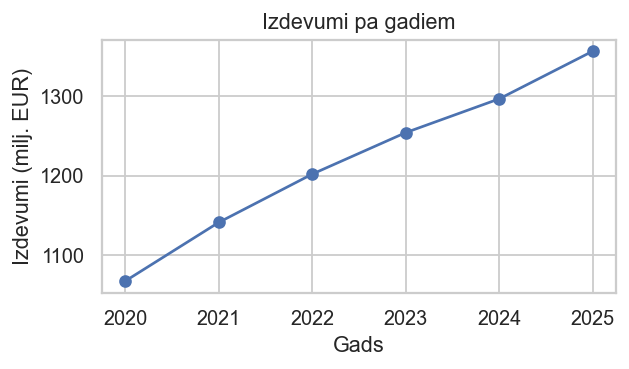

In [ ]:
# Uzzīmējiet līniju grafiku ar `matplotlib` no `izdevumi_pa_gadiem`
# x ass: `gads`, y ass: `izdevumi_milj_eur`
# Pievienojiet virsrakstu, asu nosaukumus, `tight_layout()` un parādiet grafiku
# Papildu uzdevums: saglabājiet grafiku PNG failā

# ja mums nav matplotlib importetā tad
# import matplotlib.pyplot as plt # būtu tad vajadzīgs
# mums nevajag jo pirmajā šūnā jau uzstādījām

# sāksim ar pašu vienkāršako līniju diagramu bez papildu uzstādījumiem
# plt.plot(izdevumi_pa_gadiem["gads"], izdevumi_pa_gadiem["izdevumi_milj_eur"])

# uzstādīsim izmēru vispirms
plt.figure(figsize=(5,3)) # 5 un 3 ir collas

# labāk ar marķieriem
plt.plot(izdevumi_pa_gadiem["gads"], izdevumi_pa_gadiem["izdevumi_milj_eur"], marker="o")
plt.xlabel("Gads")
plt.ylabel("Izdevumi (milj. EUR)")
plt.title("Izdevumi pa gadiem")
plt.tight_layout() # palīdz pie saglabāšanas
# saglabāsim png failā, ar dpi 300, derēs vidējas kvalitātes izdrukai
plt.savefig("izdevumi_pa_gadiem.png", dpi=300, bbox_inches='tight')
plt.show() # show nav obligāts
# es varētu taisīt daudzas vizualizācijas un glabāt bez show



In [ ]:
# vēl viens svarīgs moments ir ka plt strādā viena šunas ietvaros

# dataframe un citi mainīgie ir pieejami visās šūnās, bet plt.show() un plt.savefig() strādā tikai tajā šūnā, kurā tie ir izsaukti, tāpēc ir svarīgi saprast, ka vizualizācijas tiek renderētas un saglabātas konkrētajā šūnā, kurā tās tiek izveidotas. Ja mēs mēģinātu parādīt vai saglabāt grafiku citā šūnā bez atkārtotas definēšanas, tas nedarbotos, jo plt.plot() un citi vizualizācijas komandas ir jāizsauc tajā pašā šūnā, kurā mēs vēlamies redzēt vai saglabāt rezultātu.

# plt jaunā šūnā būs jaunai vizualizācijai, un ja mēs mēģinātu parādīt iepriekšējo grafiku, tas nedarbotos, jo plt.show() un plt.savefig() strādā tikai tajā šūnā, kurā tie ir izsaukti. Tāpēc ir svarīgi saprast, ka vizualizācijas tiek renderētas un saglabātas konkrētajā šūnā, kurā tās tiek izveidotas. Ja mēs vēlamies redzēt vai saglabāt grafiku citā šūnā, mums jāatkārto vizualizācijas komandas tajā šūnā.

### Uzdevums 4.2. Stabiņu grafiks pa kategorijām

Izveidojiet grafiku, kas salīdzina **kopējos izdevumus pa kategorijām**.

**Padoms:** pirms zīmēšanas sakārtojiet rezultātu dilstošā secībā.


In [ ]:
# Parādiet datu pirmās rindas ar `df.head()`


In [ ]:
# Apskatiet kategoriju sadalījumu ar `value_counts()` kolonnai `kategorija`


In [ ]:
# Izveidojiet DataFrame `izdevumi_pa_kategorijam`
# Grupējiet datus pēc `kategorija` un saskaitiet `izdevumi_milj_eur` summu
# Parādiet rezultātu


In [ ]:
# Sakārtojiet `izdevumi_pa_kategorijam` dilstoši pēc `izdevumi_milj_eur`
# Pēc tam parādiet sakārtoto rezultātu


In [ ]:
# Izveidojiet stabiņu diagrammu ar `matplotlib` no `izdevumi_pa_kategorijam`
# Pievienojiet virsrakstu, asu nosaukumus un pagrieziet x ass etiķetes labākai salasāmībai
# Noformējiet režģi un parādiet grafiku
# Papildu uzdevums: saglabājiet grafiku PNG failā


In [ ]:
# Papildiniet stabiņu diagrammu, pievienojot vērtības virs katra stabiņa
# Padoms: izmantojiet ciklu un `plt.text(...)`


In [ ]:
# Izveidojiet arī pīrāga diagrammu no `izdevumi_pa_kategorijam`
# Pievienojiet kategoriju etiķetes, procentu attēlojumu un virsrakstu
# Papildu uzdevums: saglabājiet grafiku PNG failā


### Uzdevums 4.3. Vairākas līnijas vienā grafikā

Izveidojiet grafiku, kur katra līnija rāda viena reģiona kopējos izdevumus pa gadiem.


In [ ]:
# Parādiet datu pirmās rindas ar `df.head()`


In [ ]:
# Izveidojiet tabulu ar izdevumiem pa gadiem un reģioniem
# Izmantojiet `pivot_table(...)` vai `groupby(...)`
# Rindas: `gads`, kolonnas: `regions`, vērtības: `izdevumi_milj_eur`, funkcija: summa
# Saglabājiet rezultātu mainīgajā `pivot_table` un parādiet to


In [ ]:
# Uzzīmējiet vairākas līnijas vienā `matplotlib` grafikā no `pivot_table`
# Katram reģionam izveidojiet atsevišķu līniju
# Pievienojiet virsrakstu, asu nosaukumus, leģendu un parādiet grafiku
# Papildu uzdevums: saglabājiet grafiku PNG failā


In [ ]:
# Papildu uzdevums: izveidojiet melnbaltu versiju šim pašam grafikam
# Lai līnijas atšķirtos, izmantojiet dažādus līniju stilus un marķierus


## 5. Seaborn statistiskās vizualizācijas

Seaborn ir īpaši ērts statistisku sadalījumu un salīdzinājumu attēlošanai.


### Uzdevums 5.1. Histogramma

Izveidojiet histogrammu kolonnai `iedzivotaju_apmierinatiba`.

**Prasības:**
- izmantojiet `sns.histplot`,
- norādiet binu skaitu,
- pievienojiet nosaukumu.


In [ ]:
# Parādiet datu pirmās rindas ar `df.head()`


In [ ]:
# Aprēķiniet statistisko kopsavilkumu kolonnai `iedzivotaju_apmierinatiba`


In [ ]:
# Noskaidrojiet pašreizējo `matplotlib` bāzes fonta izmēru ar `plt.rcParams[...]`


In [ ]:
# Izveidojiet histogrammu kolonnai `iedzivotaju_apmierinatiba` ar `sns.histplot(...)`
# Izvēlieties binu skaitu un pievienojiet KDE līniju
# Pievienojiet virsrakstu, asu nosaukumus, `tight_layout()` un parādiet grafiku
# Papildu uzdevums: saglabājiet grafiku PNG failā


### Uzdevums 5.2. Boxplot pa kategorijām

Izveidojiet boxplot, kas salīdzina iedzīvotāju apmierinātību dažādās kategorijās.

Vairāk par boxplot: https://en.wikipedia.org/wiki/Box_plot
Seaborn dokumentācija: https://seaborn.pydata.org/generated/seaborn.boxplot.html


In [ ]:
# Parādiet datu pirmās rindas ar `df.head()`


In [ ]:
# Izveidojiet boxplot ar `sns.boxplot(...)`
# x ass: `kategorija`, y ass: `iedzivotaju_apmierinatiba`
# Pievienojiet virsrakstu, asu nosaukumus un parādiet grafiku
# Papildu uzdevums: saglabājiet grafiku PNG failā


### Uzdevums 5.3. Scatter plot

Izveidojiet izkliedes grafiku, kur:
- x ass = `izdevumi_milj_eur`
- y ass = `iedzivotaju_apmierinatiba`
- krāsa = `kategorija`


In [ ]:
# Izveidojiet scatter plot ar `sns.scatterplot(...)`
# x ass: `izdevumi_milj_eur`, y ass: `iedzivotaju_apmierinatiba`
# Krāsojiet punktus pēc `kategorija`
# Pievienojiet virsrakstu, asu nosaukumus, leģendu un parādiet grafiku
# Papildu uzdevums: saglabājiet grafiku PNG failā


### Uzdevums 5.4. Korelāciju heatmap

Izveidojiet korelāciju matricu tikai skaitliskajām kolonnām un attēlojiet to ar `sns.heatmap`.


In [ ]:
# Atlasiet tikai skaitliskās kolonnas un saglabājiet tās `numeric_df`
# Aprēķiniet korelāciju matricu un saglabājiet to `correlation_matrix`
# Uzzīmējiet heatmap ar `sns.heatmap(...)`
# Pievienojiet virsrakstu, `tight_layout()` un parādiet grafiku
# Papildu uzdevums: saglabājiet grafiku PNG failā


## Korelācija nenozīme causation

Korelācijas pašas par sevi nenozīme ciešu likumsakarību!

## 6. Interaktīvās vizualizācijas ar Plotly

Šeit uzdevums ir sajust atšķirību starp statiskiem un interaktīviem grafikiem.


### Uzdevums 6.1. Interaktīvs līniju grafiks

Ar Plotly izveidojiet interaktīvu grafiku kopējiem izdevumiem pa gadiem.


In [ ]:
# Izveidojiet interaktīvu līniju grafiku ar `plotly.express.line(...)`
# Izmantojiet `izdevumi_pa_gadiem`, x ass `gads`, y ass `izdevumi_milj_eur`
# Pievienojiet virsrakstu un parādiet grafiku ar `fig.show()`


### Uzdevums 6.2. Interaktīvs stabiņu grafiks

Izveidojiet interaktīvu stabiņu grafiku izdevumiem pa kategorijām.


In [ ]:
# Izveidojiet interaktīvu stabiņu diagrammu ar `plotly.express.bar(...)`
# Izmantojiet `izdevumi_pa_kategorijam` un parādiet grafiku ar `fig.show()`


### Uzdevums 6.3. Interaktīvs scatter plot

Izveidojiet Plotly scatter plot ar:
- krāsu pēc kategorijas,
- punkta izmēru pēc projektu skaita,
- hover informāciju par gadu un reģionu.


In [ ]:
# Izveidojiet interaktīvu scatter plot ar `plotly.express.scatter(...)`
# x ass: `izdevumi_milj_eur`, y ass: `iedzivotaju_apmierinatiba`, krāsa pēc `kategorija`
# Papildu uzdevums: pielāgojiet punktu izmēru vai etiķetes


## 7. Prezentācijām piemēroti grafiki

Aplūkojiet savus iepriekš veidotos grafikus un uzlabojiet vismaz vienu no tiem tā, lai tas būtu piemērots prezentācijai.

### Pārbaudiet:
- vai virsraksts ir skaidrs;
- vai etiķetes ir salasāmas;
- vai nav pārāk daudz vizuāla trokšņa;
- vai ir saprotams galvenais vēstījums.


In [ ]:
# Izvēlieties vienu iepriekšējo grafiku un uzlabojiet to prezentācijai
# Padomājiet par krāsām, fontiem, anotācijām, izmēru un kopējo salasāmību


## 8. Mini projekts

Izveidojiet 3 grafikus:
1. **Matplotlib** — tendence laikā;
2. **Seaborn** — sadalījums vai salīdzinājums;
3. **Plotly** — interaktīva izpēte.

Pie katra grafikā zemāk uzrakstiet īsu interpretāciju:
- ko grafiks rāda,
- kāds ir galvenais secinājums.


In [ ]:
# Izveidojiet 3 grafikus:
# 1. Matplotlib grafiku ar tendenci laikā
# 2. Seaborn grafiku ar salīdzinājumu vai sadalījumu
# 3. Plotly interaktīvu grafiku
# 4. Zem šīs šūnas Markdown formā uzrakstiet īsu interpretāciju par iegūtajiem rezultātiem


## 9. Pašpārbaudes jautājumi

1. Kad labāk izmantot līniju grafiku, nevis stabiņu grafiku?
2. Kādos gadījumos Seaborn ir ērtāks par Matplotlib?
3. Kāda ir Plotly galvenā priekšrocība?
4. Kāpēc korelācija vēl nenozīmē cēloņsakarību?
5. Kādas ir 3 biežākās kļūdas sliktā grafikā?
